# Longest Easiest Fixture Run — Playground #3

Which teams have the longest run of **easy fixtures** coming up? A team with 5-6 consecutive easy games is worth loading multiple squad slots into.

**CS problem:** *longest subarray satisfying a predicate* (every FDR ≤ T) over each team's per-gameweek difficulty sequence — the classic **sliding-window / two-pointer** pattern. The fixture ticker is a `team × gameweek` **matrix**; each row is a 1-D array we slide over.

**Method**
1. Build a per-team, per-GW difficulty table (from that team's own perspective, home/away aware).
2. Slide a window over upcoming GWs; find the longest maximal run where **every** FDR ≤ `T`.
3. Rank teams by run **length** first, then **easiness** (lower avg FDR).
4. Handle **DGW** (two fixtures in one GW → counts as two easy games) and **BGW** (no fixture → breaks a run).

**FDR source (`FDR_SOURCE` in Config):** either FPL's own pre-season `team_h/a_difficulty`, or the
**data-derived, venue-aware strength rating** from [#06](../06-team-fixture-proof/team_fixture_proof.ipynb)
(`team_strength_fdr.csv`). The strength source is also **role-aware** via `FDR_ROLE`: run the ticker
on `attack` difficulty for a **forward/mid** fixture run (opponents easy to score against), on
`defence` for a **defender/GK** run (opponents easy to keep clean sheets against), or `overall` for
general planning. Newly promoted teams are pinned to the easiest rating.

Data: `https://fantasy.premierleague.com/api/fixtures/` (`team_h_difficulty` / `team_a_difficulty`) and `.../bootstrap-static/` for team names + current GW.

Edit the **Config** cell, then *Run All*.

## Config — edit me

In [14]:
FIXTURES_URL = "https://fantasy.premierleague.com/api/fixtures/"
BOOTSTRAP_URL = "https://fantasy.premierleague.com/api/bootstrap-static/"

# FDR source for the ticker:
#   "fpl"      -> FPL's own pre-season team_h_difficulty / team_a_difficulty (integer 1-5).
#   "strength" -> data-derived, venue-aware rating exported by notebook #06
#                 (per-opponent home/away difficulty from last season's points + goals).
FDR_SOURCE = "strength"
STRENGTH_CSV = "../06-team-fixture-proof/team_strength_fdr.csv"

# Which strength FDR to run the ticker on (only used when FDR_SOURCE == "strength"):
#   "overall" -> general team strength (all-rounder / captaincy planning).
#   "attack"  -> for your FORWARDS/MIDS: ranks opponents by how easy they are to SCORE against
#                (driven by the opponent's goals conceded).
#   "defence" -> for your DEFENDERS/GK: ranks opponents by how easy a CLEAN SHEET is
#                (driven by the opponent's goals scored).
FDR_ROLE = "attack"

# Newly promoted teams have no top-flight history in the strength table (e.g. Ipswich, Hull,
# Coventry). Any upcoming team missing from the CSV is auto-treated as the EASIEST fixture to
# face — the lowest rating on the scale. Tune if you want promoted sides rated slightly harder.
PROMOTED_FDR = 1.0

# A fixture is "easy" when its FDR is at or below this threshold. Tune 2 (very strict) or 3 (looser).
DIFFICULTY_THRESHOLD = 3.2

# How many upcoming gameweeks to look ahead from the next GW.
HORIZON = 19

# DGW aggregation: how to collapse two fixtures in one GW into a single cell FDR for the run test.
# "max" = the run only survives if BOTH games are easy (conservative). "mean" = average of the two.
DGW_AGG = "max"

# Fixed window length for the best/worst-stretch scan (e.g. 3 = a mini planning window, 6 = a wildcard horizon).
WINDOW_K = 5

# Bad fixture run: a maximal block of non-easy games (FDR >= BAD_FLOOR) that is at least
# BAD_MIN_LEN GWs long AND whose mean FDR is strictly above BAD_AVG. e.g. 4,3,3,3 -> avg 3.25 -> bad.
BAD_MIN_LEN = 3
BAD_FLOOR = 3   # an easy game (FDR < this) breaks the bad run
BAD_AVG = 3.25     # flagged only when the run's mean FDR is strictly greater than this

## Fetch

In [15]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

HEADERS = {"User-Agent": "Mozilla/5.0"}

boot = requests.get(BOOTSTRAP_URL, headers=HEADERS, timeout=30).json()
fixtures = requests.get(FIXTURES_URL, headers=HEADERS, timeout=30).json()

team_name = {t["id"]: t["short_name"] for t in boot["teams"]}

# Current/next GW: the first event flagged is_next, else first not-finished.
next_gw = next((e["id"] for e in boot["events"] if e.get("is_next")), None)
if next_gw is None:
    next_gw = next((e["id"] for e in boot["events"] if not e["finished"]), 1)

print(f"{len(fixtures)} fixtures, {len(team_name)} teams. Next GW = {next_gw}, horizon = {next_gw}–{next_gw + HORIZON - 1}.")

380 fixtures, 20 teams. Next GW = 1, horizon = 1–19.


## Build the per-team difficulty table

Each fixture yields **two** rows — one per team, from that team's own perspective. The FDR each
team carries depends on `FDR_SOURCE` (and, for strength, `FDR_ROLE`):

- **`fpl`** — the home team carries `team_h_difficulty`, the away team `team_a_difficulty`.
- **`strength`** — each side's difficulty is the **opponent's venue-specific rating** from
  notebook #06: the home side faces an *away* opponent (`{role}_at_away`), the away side a *home*
  opponent (`{role}_at_home`). `FDR_ROLE` picks the lens — `overall`, `attack` (rank opponents by
  how easy they are to score against → for your **FWD/MID**), or `defence` (by clean-sheet odds →
  for your **DEF/GK**). Newly promoted teams (no history) score as the **easiest** fixture
  (`PROMOTED_FDR`).

We keep only upcoming GWs inside the horizon.

In [16]:
gw_max = next_gw + HORIZON - 1

# Choose how each fixture's difficulty is scored.
if FDR_SOURCE == "strength":
    strength = pd.read_csv(STRENGTH_CSV, index_col="short")
    # Pick the role's two columns: facing them when THEY are home / away.
    d_at_home = strength[f"{FDR_ROLE}_at_home"].to_dict()
    d_at_away = strength[f"{FDR_ROLE}_at_away"].to_dict()
    promoted = sorted(set(team_name.values()) - set(strength.index))
    print(f"FDR source: strength rating (#06), role={FDR_ROLE!r}. "
          f"Promoted/unrated -> FDR {PROMOTED_FDR} (easiest): {promoted or 'none'}")

    def opp_fdr(opp_short, opp_is_home):
        """Difficulty of facing `opp_short`; missing team (newly promoted) = easiest fixture."""
        table = d_at_home if opp_is_home else d_at_away
        return round(table.get(opp_short, PROMOTED_FDR), 2)
else:
    print("FDR source: FPL team_h_difficulty / team_a_difficulty")

rows = []
for f in fixtures:
    gw = f["event"]
    if gw is None or gw < next_gw or gw > gw_max:
        continue
    h, a = f["team_h"], f["team_a"]
    if FDR_SOURCE == "strength":
        # Home side faces the AWAY opponent (opp is away); away side faces the HOME opponent.
        h_fdr = opp_fdr(team_name[a], opp_is_home=False)
        a_fdr = opp_fdr(team_name[h], opp_is_home=True)
    else:
        h_fdr, a_fdr = f["team_h_difficulty"], f["team_a_difficulty"]
    rows.append({"team": h, "gw": gw, "opp": a, "where": "H", "fdr": h_fdr})
    rows.append({"team": a, "gw": gw, "opp": h, "where": "A", "fdr": a_fdr})

long = pd.DataFrame(rows)
long["team"] = long["team"].map(team_name)
long["opp"] = long["opp"].map(team_name)
long["label"] = long["opp"] + " (" + long["where"] + ")"
print(f"{len(long)} team-fixture rows across GW {next_gw}–{gw_max}")
long.sort_values(["team", "gw"]).head(12)

FDR source: strength rating (#06), role='attack'. Promoted/unrated -> FDR 1.0 (easiest): ['COV', 'HUL', 'IPS']
380 team-fixture rows across GW 1–19


,team,gw,opp,where,fdr,label
0,ARS,1,COV,H,1.00,COV (H)
39,ARS,2,AVL,A,3.74,AVL (A)
58,ARS,3,CHE,H,3.17,CHE (H)
73,ARS,4,SUN,A,3.97,SUN (A)
85,ARS,5,BHA,A,3.97,BHA (A)
100,ARS,6,LEE,H,2.26,LEE (H)
137,ARS,7,NFO,A,3.63,NFO (A)
140,ARS,8,EVE,H,3.63,EVE (H)
173,ARS,9,LIV,A,3.97,LIV (A)
180,ARS,10,HUL,H,1.00,HUL (H)


## Fixture ticker matrix (team × GW)

Pivot into the classic ticker. **DGW** cells collapse two fixtures per `DGW_AGG`; **BGW** cells are `NaN` (no fixture). `games` counts fixtures per cell so DGWs count double later.

In [27]:
gws = list(range(next_gw, gw_max + 1))
agg = "max" if DGW_AGG == "max" else "mean"

fdr = long.pivot_table(index="team", columns="gw", values="fdr", aggfunc=agg).reindex(columns=gws)
games = long.pivot_table(index="team", columns="gw", values="fdr", aggfunc="count").reindex(columns=gws).fillna(0).astype(int)
labels = long.groupby(["team", "gw"])["label"].apply(lambda s: " + ".join(s)).unstack().reindex(columns=gws)

# Sort teams by their overall easiness across the horizon for a nice default view.
fdr = fdr.loc[fdr.mean(axis=1).sort_values().index]
labels = labels.reindex(fdr.index)
games = games.reindex(fdr.index)
fdr.round(1)
# Sort teams by gw 1 FDR for a more "first-impression" view.
fdr = fdr.loc[fdr[gws[1]].sort_values().index]
fdr

gw,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
team,,,,,,,,,,,,,,,,,,,
MUN,1.00,1.00,3.17,3.86,3.97,3.29,3.86,2.37,3.40,3.17,3.97,2.71,2.83,1.00,3.63,5.00,3.06,3.06,3.97
HUL,3.29,1.00,3.17,3.40,2.83,3.63,3.97,2.71,1.00,5.00,3.29,3.63,3.06,3.97,3.29,4.66,2.49,2.26,3.97
COV,5.00,1.00,4.66,3.29,3.63,3.40,2.71,2.71,3.06,3.17,3.06,3.86,1.00,3.51,3.17,3.97,3.17,2.71,3.97
SUN,1.00,2.71,3.86,4.43,4.66,3.29,3.97,2.26,1.00,3.17,3.74,3.29,3.97,2.83,3.06,3.06,3.17,3.51,1.00
LEE,3.63,2.71,3.97,3.40,3.06,5.00,3.29,3.97,3.97,3.29,3.40,1.00,4.66,1.00,3.97,2.71,3.74,1.00,3.63
NEW,2.49,2.71,2.37,3.86,1.00,1.00,3.17,3.63,3.63,3.97,4.43,3.97,3.29,3.06,1.00,3.86,3.86,3.06,3.40
LIV,2.83,3.06,1.00,2.71,3.97,3.86,3.86,3.29,4.43,3.63,3.29,3.17,3.06,3.40,2.26,3.29,1.00,3.74,1.00
CHE,3.97,3.29,5.00,1.00,3.86,2.37,3.17,3.29,3.29,3.97,2.26,3.63,3.06,2.49,4.66,3.17,1.00,1.00,3.40
BHA,3.17,3.40,2.26,1.00,4.43,3.97,3.06,3.97,4.66,2.71,1.00,3.40,3.97,3.63,3.63,1.00,3.97,2.71,3.29


## Sliding window — longest easy run per team

For each team we scan its GW row left-to-right, extending the current run while the cell exists (not a BGW) **and** its FDR ≤ `T`. Any harder game or a blank GW resets the run. We keep each team's best (longest) run, breaking ties by lower average FDR. `games` sums fixtures so a DGW inside the run counts as two easy games.

In [18]:
T = DIFFICULTY_THRESHOLD

def longest_run(team):
    row = fdr.loc[team]
    best = None            # (length, start_gw, end_gw)
    start = None
    for gw in gws:
        v = row[gw]
        ok = pd.notna(v) and v <= T
        if ok:
            if start is None:
                start = gw
            cur = (gw - start + 1, start, gw)
            if best is None or cur[0] > best[0]:
                best = cur
        else:
            start = None
    if best is None:
        return None
    length, s, e = best
    span = [g for g in gws if s <= g <= e]
    return {
        "team": team,
        "start_gw": s,
        "end_gw": e,
        "length": length,
        "games": int(games.loc[team, span].sum()),
        "avg_fdr": round(float(fdr.loc[team, span].mean()), 2),
        "fixtures": ", ".join(f"GW{g}:{labels.loc[team, g]}" for g in span),
    }

runs = pd.DataFrame([r for r in (longest_run(t) for t in fdr.index) if r])
runs = runs.sort_values(["length", "avg_fdr"], ascending=[False, True]).reset_index(drop=True)
print(f"Teams with at least one run of FDR ≤ {T}: {len(runs)}")
runs[["team", "start_gw", "end_gw", "length", "games", "avg_fdr"]].head(15)

Teams with at least one run of FDR ≤ 3.2: 20


,team,start_gw,end_gw,length,games,avg_fdr
0,IPS,8,13,6,6,2.22
1,AVL,3,7,5,5,2.46
2,COV,7,11,5,5,2.94
3,CRY,9,12,4,4,1.80
4,EVE,4,7,4,4,1.97
5,LIV,1,4,4,4,2.40
6,MCI,15,18,4,4,2.54
7,FUL,12,15,4,4,2.74
8,SUN,14,17,4,4,3.03
9,CHE,16,18,3,3,1.72


### The winning runs, with fixtures spelled out

In [19]:
with pd.option_context("display.max_colwidth", None):
    display(runs.head(9)[["team", "length", "games", "avg_fdr", "fixtures"]])

,team,length,games,avg_fdr,fixtures
0,IPS,6,6,2.22,"GW8:NFO (H), GW9:HUL (A), GW10:BOU (H), GW11:TOT (A), GW12:AVL (H), GW13:COV (A)"
1,AVL,5,5,2.46,"GW3:HUL (A), GW4:NFO (H), GW5:TOT (A), GW6:BRE (H), GW7:NEW (A)"
2,COV,5,5,2.94,"GW7:TOT (A), GW8:FUL (H), GW9:SUN (H), GW10:EVE (A), GW11:CRY (H)"
3,CRY,4,4,1.80,"GW9:TOT (A), GW10:LIV (H), GW11:COV (A), GW12:HUL (H)"
4,EVE,4,4,1.97,"GW4:TOT (A), GW5:IPS (H), GW6:HUL (A), GW7:CHE (H)"
5,LIV,4,4,2.40,"GW1:NEW (A), GW2:NFO (H), GW3:IPS (A), GW4:FUL (H)"
6,MCI,4,4,2.54,"GW15:CHE (H), GW16:HUL (H), GW17:NEW (A), GW18:EVE (A)"
7,FUL,4,4,2.74,"GW12:BOU (H), GW13:TOT (A), GW14:EVE (A), GW15:BRE (H)"
8,SUN,4,4,3.03,"GW14:NEW (A), GW15:NFO (H), GW16:CRY (H), GW17:EVE (A)"


## Runs that start *right now* (start_gw = next GW)

The longest-run table above rewards streaks that may not begin for a few GWs — you'd have to wait (and transfer in later) to benefit. Here we instead measure each team's **prefix run**: the streak of easy fixtures starting from the very first horizon GW. These are the teams worth buying *today*, no waiting. Ranked by prefix length, then avg FDR.

In [20]:
def prefix_run(team):
    """Easy streak starting from the very first horizon GW (breaks at first hard/blank GW)."""
    row = fdr.loc[team]
    span = []
    for gw in gws:
        v = row[gw]
        if pd.notna(v) and v <= T:
            span.append(gw)
        else:
            break
    if not span:
        return None
    return {
        "team": team,
        "start_gw": span[0],
        "end_gw": span[-1],
        "length": len(span),
        "games": int(games.loc[team, span].sum()),
        "avg_fdr": round(float(fdr.loc[team, span].mean()), 2),
        "fixtures": ", ".join(f"GW{g}:{labels.loc[team, g]}" for g in span),
    }

prefix = pd.DataFrame([r for r in (prefix_run(t) for t in fdr.index) if r])
prefix = prefix.sort_values(["length", "avg_fdr"], ascending=[False, True]).reset_index(drop=True)
print(f"Teams easy from GW{next_gw} onward: {len(prefix)}")
with pd.option_context("display.max_colwidth", None):
    display(prefix.head(9)[["team", "length", "games", "avg_fdr", "fixtures"]])

Teams easy from GW1 onward: 12


,team,length,games,avg_fdr,fixtures
0,LIV,4,4,2.40,"GW1:NEW (A), GW2:NFO (H), GW3:IPS (A), GW4:FUL (H)"
1,MUN,3,3,1.72,"GW1:HUL (A), GW2:IPS (H), GW3:EVE (A)"
2,NEW,3,3,2.52,"GW1:LIV (H), GW2:TOT (A), GW3:BOU (H)"
3,SUN,2,2,1.85,"GW1:IPS (A), GW2:FUL (H)"
4,ARS,1,1,1.00,GW1:COV (H)
5,NFO,1,1,2.26,GW1:LEE (H)
6,MCI,1,1,2.37,GW1:BOU (H)
7,EVE,1,1,3.06,GW1:CRY (H)
8,IPS,1,1,3.06,GW1:SUN (H)


## Bad fixture runs — teams to avoid

The inverse of the easy run. A **bad run** is a maximal block of non-easy games (FDR ≥ `BAD_FLOOR`) that is at least `BAD_MIN_LEN` GWs long **and** whose mean FDR is strictly above `BAD_AVG`. An easy game (FDR below the floor) breaks the block — a mid-run reprieve doesn't count as a bad stretch. e.g. `4, 3, 3, 3` → avg 3.25 → **bad**; a flat `3, 3, 3` → avg exactly 3 → not flagged.

These are the teams whose players you'd want to sell or bench through the block. A team can appear more than once if it has two separate bad stretches. Ranked hardest first (highest avg FDR, then longest).

In [21]:
def bad_runs(team):
    """All maximal FDR>=BAD_FLOOR blocks that are long enough and average above BAD_AVG."""
    row = fdr.loc[team]
    out, span = [], []

    def flush():
        if len(span) >= BAD_MIN_LEN:
            avg = float(fdr.loc[team, span].mean())
            if avg > BAD_AVG:
                out.append({
                    "team": team,
                    "start_gw": span[0],
                    "end_gw": span[-1],
                    "length": len(span),
                    "games": int(games.loc[team, span].sum()),
                    "avg_fdr": round(avg, 2),
                    "fixtures": ", ".join(f"GW{g}:{labels.loc[team, g]}" for g in span),
                })

    for gw in gws:
        v = row[gw]
        if pd.notna(v) and v >= BAD_FLOOR:
            span.append(gw)
        else:
            flush()
            span = []
    flush()
    return out

bad = pd.DataFrame([r for team in fdr.index for r in bad_runs(team)])
if len(bad):
    bad = bad.sort_values(["avg_fdr", "length"], ascending=[False, False]).reset_index(drop=True)
print(f"Bad runs (len>={BAD_MIN_LEN}, avg FDR>{BAD_AVG}): {len(bad)}")
with pd.option_context("display.max_colwidth", None):
    display(bad[["team", "start_gw", "end_gw", "length", "games", "avg_fdr", "fixtures"]] if len(bad) else bad)

Bad runs (len>=3, avg FDR>3.25): 40


,team,start_gw,end_gw,length,games,avg_fdr,fixtures
0,CHE,1,3,3,3,4.09,"GW1:FUL (A), GW2:BHA (H), GW3:ARS (A)"
1,SUN,3,7,5,5,4.04,"GW3:BRE (A), GW4:ARS (H), GW5:MCI (A), GW6:BHA (H), GW7:BOU (A)"
2,BHA,5,9,5,5,4.02,"GW5:ARS (H), GW6:SUN (A), GW7:CRY (H), GW8:LIV (A), GW9:MCI (A)"
3,FUL,9,11,3,3,3.93,"GW9:AVL (A), GW10:NEW (H), GW11:MCI (A)"
4,HUL,10,16,7,7,3.84,"GW10:ARS (A), GW11:BHA (H), GW12:CRY (A), GW13:NFO (H), GW14:BOU (A), GW15:TOT (H), GW16:MCI (A)"
5,FUL,16,19,4,4,3.80,"GW16:LEE (A), GW17:BHA (H), GW18:ARS (H), GW19:NFO (A)"
6,CRY,13,17,5,5,3.77,"GW13:CHE (A), GW14:AVL (A), GW15:MUN (H), GW16:SUN (A), GW17:ARS (H)"
7,COV,3,6,4,4,3.75,"GW3:MCI (A), GW4:BHA (H), GW5:NFO (A), GW6:NEW (H)"
8,MUN,15,19,5,5,3.74,"GW15:CRY (A), GW16:ARS (A), GW17:NFO (H), GW18:SUN (H), GW19:BHA (A)"
9,ARS,7,9,3,3,3.74,"GW7:NFO (A), GW8:EVE (H), GW9:LIV (A)"


## Fixture ticker heatmap

Classic FPL ticker: teams × GW coloured by FDR (green = easy, red = hard). Grey = **BGW** (no fixture). Teams are ordered easiest-overall at the top.

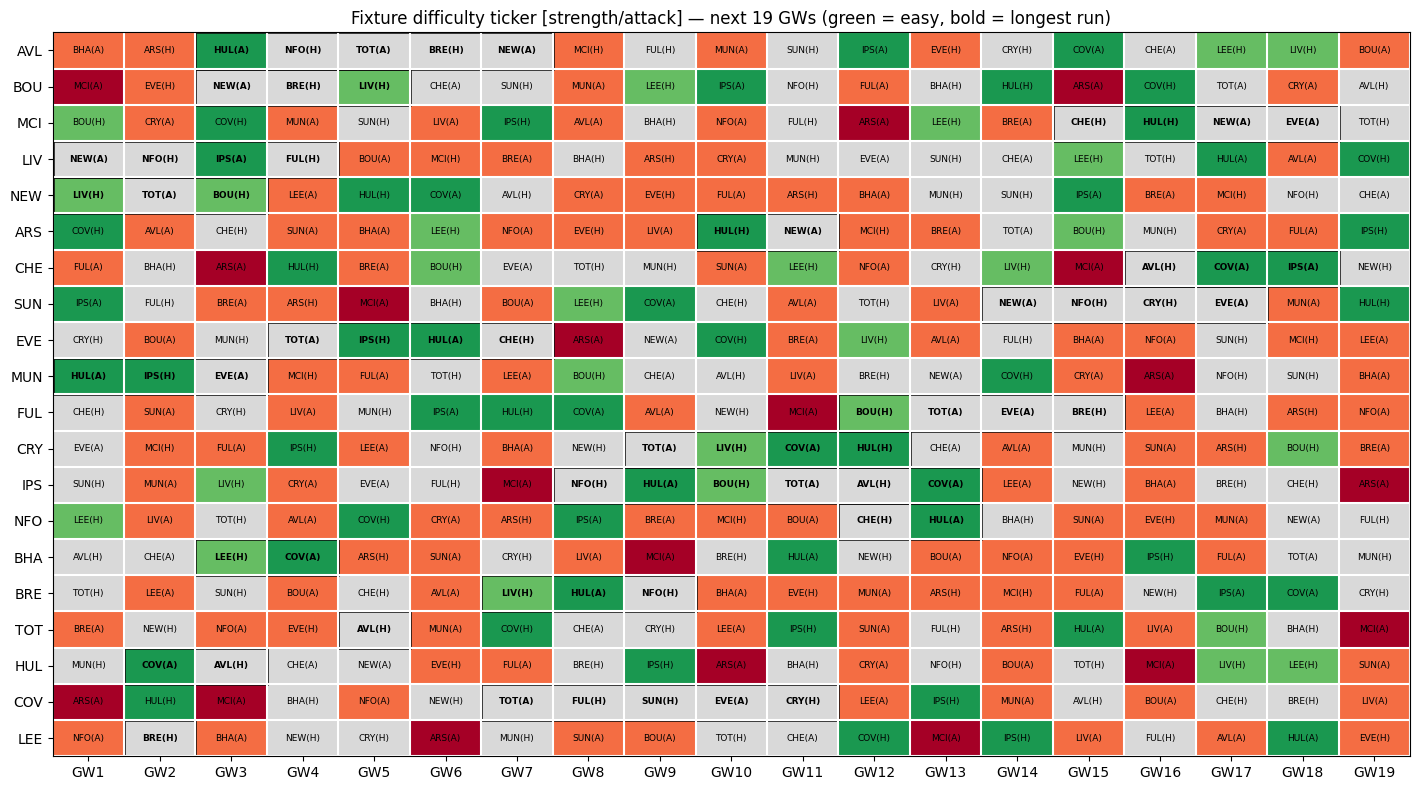

In [22]:
# FPL-style discrete colours for FDR 1..5.
fdr_colors = ["#1a9850", "#66bd63", "#d9d9d9", "#f46d43", "#a50026"]
cmap = ListedColormap(fdr_colors)
cmap.set_bad("#efefef")  # BGW
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

# Cells that belong to a team's longest easy run — bolded and boxed below.
run_span = {r.team: (r.start_gw, r.end_gw) for r in runs.itertuples()}
run_cells = {(t, g) for t, (s, e) in run_span.items() for g in range(s, e + 1)}

M = fdr.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(1.0 + 0.7 * len(gws), 0.35 * len(fdr) + 1))
ax.imshow(np.ma.masked_invalid(M), cmap=cmap, norm=norm, aspect="auto")

src_lbl = f"strength/{FDR_ROLE}" if FDR_SOURCE == "strength" else "FPL FDR"
ax.set_xticks(range(len(gws)), [f"GW{g}" for g in gws])
ax.set_yticks(range(len(fdr)), fdr.index)
ax.set_title(f"Fixture difficulty ticker [{src_lbl}] — next {HORIZON} GWs "
             f"(green = easy, bold = longest run)")

for i, team in enumerate(fdr.index):
    for j, g in enumerate(gws):
        opp = labels.loc[team, g]
        if isinstance(opp, str):
            in_run = (team, g) in run_cells
            ax.text(j, i, opp.replace(" ", ""), ha="center", va="center",
                    fontsize=6.5, fontweight="bold" if in_run else "normal")

# Outline each team's longest run so the streak reads at a glance.
for i, team in enumerate(fdr.index):
    if team in run_span:
        s, e = run_span[team]
        x0 = gws.index(s) - 0.5
        width = gws.index(e) - gws.index(s) + 1
        ax.add_patch(plt.Rectangle((x0, i - 0.5), width, 1, fill=False,
                                   edgecolor="black", linewidth=1.8))

ax.set_xticks(np.arange(-0.5, len(gws), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(fdr), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
plt.tight_layout()
plt.show()

## Best / worst fixed-window stretch

Instead of "longest run of easy games," slide a **fixed window of `WINDOW_K` GWs** across each team's row and score every window by its mean FDR (blank GWs inside a window are ignored). This answers *"over any `WINDOW_K`-week block, who has the single easiest stretch — and when does it fall?"* — useful for timing a wildcard or a short-term buy, since it rewards a genuinely soft block rather than a long-but-mediocre streak.

- **best window** = the softest `WINDOW_K`-GW block (lowest mean FDR) → when to own that team.
- **worst window** = the hardest block (highest mean FDR) → when to sell / avoid.

In [23]:
K = WINDOW_K
starts = [s for s in gws if s + K - 1 <= gw_max]  # each window fully inside the horizon

def extremes(team):
    row = fdr.loc[team]
    scored = []
    for s in starts:
        span = list(range(s, s + K))
        block = row[span]
        if block.notna().any():  # skip all-blank windows
            scored.append((round(float(block.mean()), 2), s, s + K - 1, span))
    if not scored:
        return None
    best = min(scored, key=lambda x: x[0])
    worst = max(scored, key=lambda x: x[0])
    return {
        "team": team,
        "best_gw": f"{best[1]}-{best[2]}",
        "best_fdr": best[0],
        "worst_gw": f"{worst[1]}-{worst[2]}",
        "worst_fdr": worst[0],
        "swing": round(worst[0] - best[0], 2),  # how much fixtures ease off between blocks
        "best_fixtures": ", ".join(f"GW{g}:{labels.loc[team, g]}" for g in best[3] if isinstance(labels.loc[team, g], str)),
    }

windows = pd.DataFrame([r for r in (extremes(t) for t in fdr.index) if r])
windows = windows.sort_values(by=["best_fdr", "swing"], ascending=[True, False]).reset_index(drop=True)
print(f"Best/worst {K}-GW windows within GW{next_gw}-{gw_max}")
windows[["team", "best_gw", "best_fdr", "worst_gw", "worst_fdr", "swing"]]

Best/worst 5-GW windows within GW1-19


,team,best_gw,best_fdr,worst_gw,worst_fdr,swing
0,FUL,5-9,2.01,15-19,3.58,1.57
1,IPS,9-13,2.05,15-19,3.65,1.60
2,CRY,8-12,2.12,13-17,3.77,1.65
3,NEW,2-6,2.19,8-12,3.93,1.74
4,EVE,3-7,2.23,15-19,3.68,1.45
5,LIV,15-19,2.26,5-9,3.88,1.62
6,AVL,11-15,2.35,7-11,3.19,0.84
7,TOT,7-11,2.46,1-5,3.54,1.08
8,CHE,14-18,2.46,1-5,3.42,0.96
9,BOU,10-14,2.46,1-5,3.26,0.80


### Best vs worst window — dumbbell chart

One row per team: a **green dot** at the best (softest) window FDR, a **red dot** at the worst, connected by a line. Teams are ordered easiest-best-window at the top. A long line = big fixture **swing** (strong buy/sell timing); dots clustered low = consistently easy.

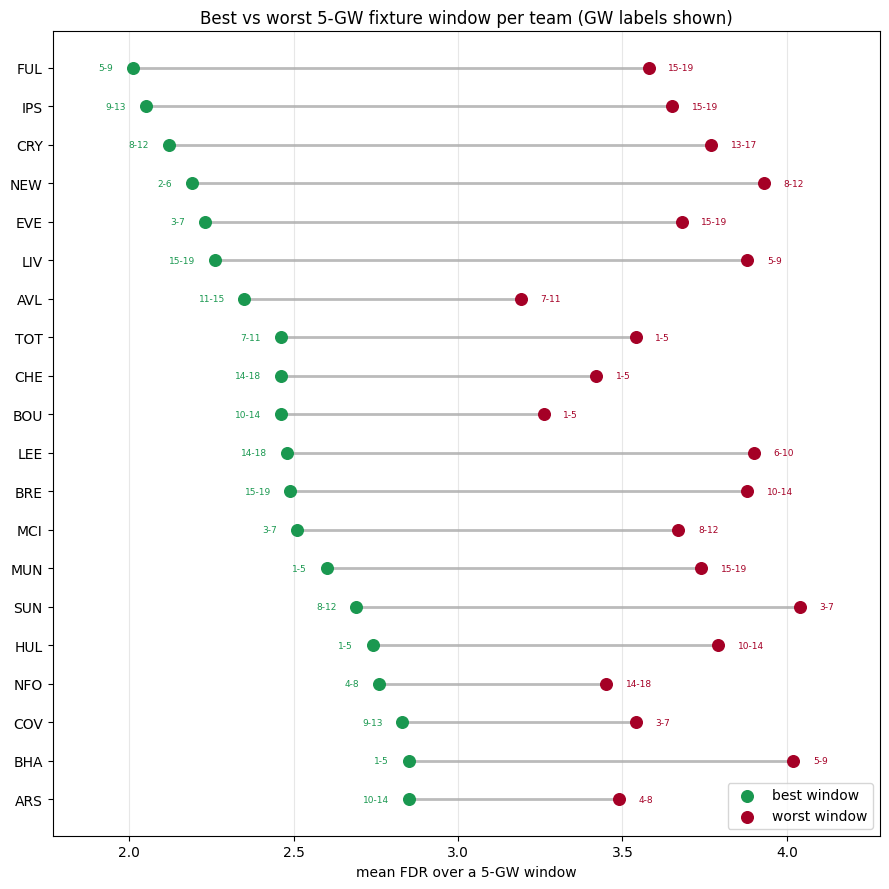

In [24]:
# Easiest best-window at the top of the chart.
w = windows.sort_values("best_fdr", ascending=False).reset_index(drop=True)
y = np.arange(len(w))

fig, ax = plt.subplots(figsize=(9, 0.4 * len(w) + 1))
ax.hlines(y, w["best_fdr"], w["worst_fdr"], color="#bbbbbb", linewidth=2, zorder=1)
ax.scatter(w["best_fdr"], y, color="#1a9850", s=70, zorder=2, label="best window")
ax.scatter(w["worst_fdr"], y, color="#a50026", s=70, zorder=2, label="worst window")

# Annotate the GW range of each endpoint.
for yi, r in zip(y, w.itertuples()):
    ax.text(r.best_fdr - 0.06, yi, r.best_gw, ha="right", va="center", fontsize=6.5, color="#1a9850")
    ax.text(r.worst_fdr + 0.06, yi, r.worst_gw, ha="left", va="center", fontsize=6.5, color="#a50026")

ax.set_yticks(y, w["team"])
ax.set_xlabel(f"mean FDR over a {K}-GW window")
ax.set_title(f"Best vs worst {K}-GW fixture window per team (GW labels shown)")
ax.margins(x=0.12)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()